<a href="https://colab.research.google.com/github/eljaysmithdata/Data-Science-Bootcamp-2026/blob/main/Project-6/Project_6_Draft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 6: Deep Learning

## Problem Statement -

Binary classification. Training set with images of cats and dogs.

## Imports

In [3]:
# ============================================================
# Import Libraries
# ============================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow.keras as keras
import tensorflow as tf
from sklearn import datasets
from keras.models import Sequential
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPooling2D
from keras.utils import plot_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
tf.config.list_physical_devices('GPU')

[]

## Data Collection

In [5]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [6]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [7]:
image_array.shape

(24946, 100, 100, 1)

In [8]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [9]:
target = pd.read_pickle( target_url )
type(target)


list

In [10]:
y = np.array(target)

In [11]:
y

array([0, 1, 1, ..., 1, 0, 1])

In [12]:
y.size

24946

In [13]:
X = np.array(image_array)

## Data Cleaning

In [16]:
X.shape, y.shape

((24946, 100, 100, 1), (24946,))

In [17]:
X.ndim

4

## Exploratory Data Analysis

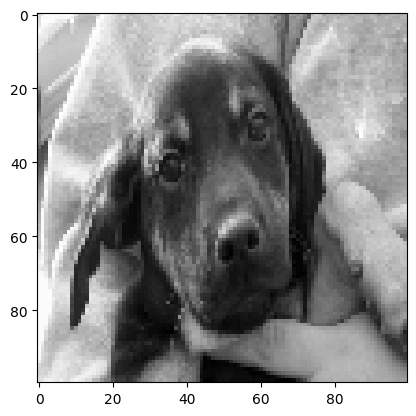

In [20]:

plt.imshow(X[42],cmap="gray")

In [21]:
y[42]

np.int64(0)

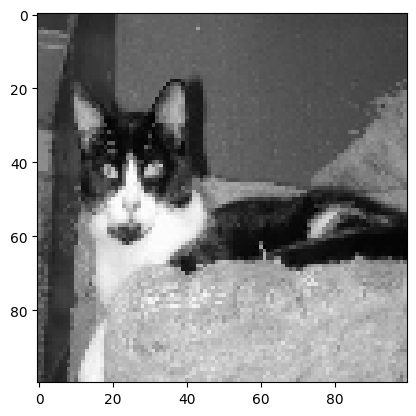

In [22]:
plt.imshow(X[95],cmap="gray")

In [23]:
y[95]

np.int64(1)

In [33]:
random_image = np.random.choice(X.shape[0], size=10, replace=False)

Label = 0


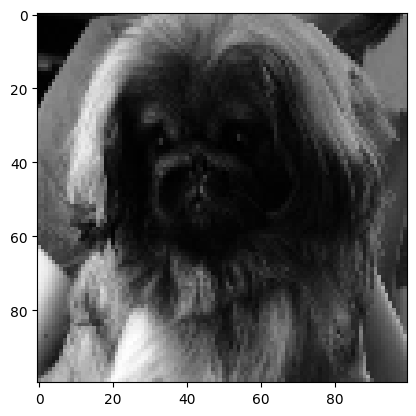

Label = 0


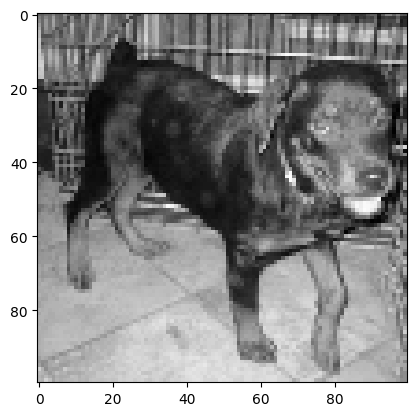

Label = 1


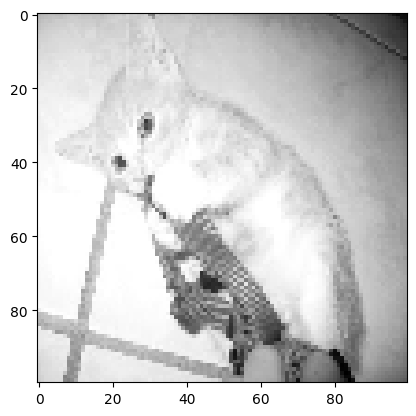

Label = 1


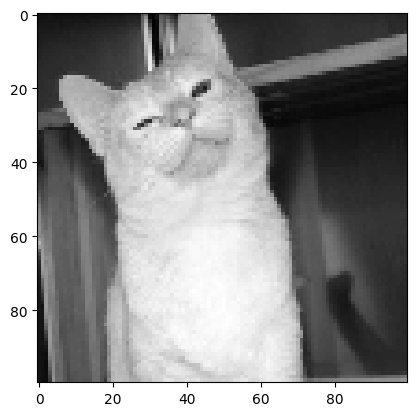

Label = 0


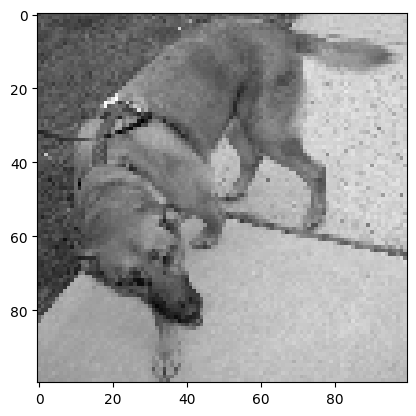

Label = 1


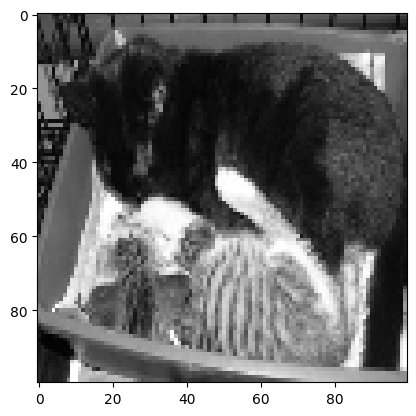

Label = 1


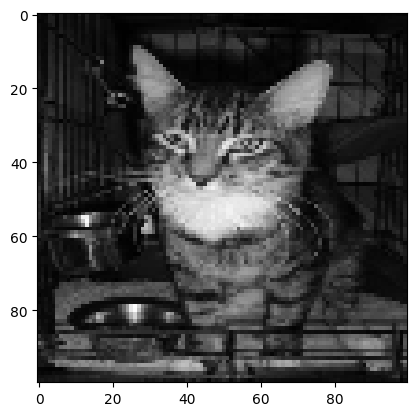

Label = 0


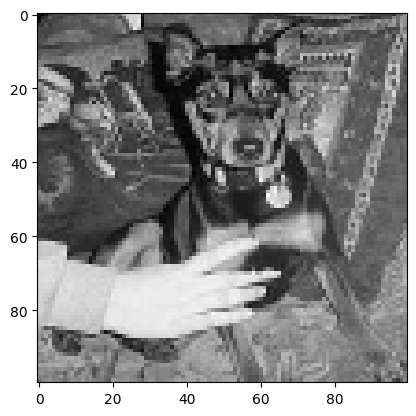

Label = 1


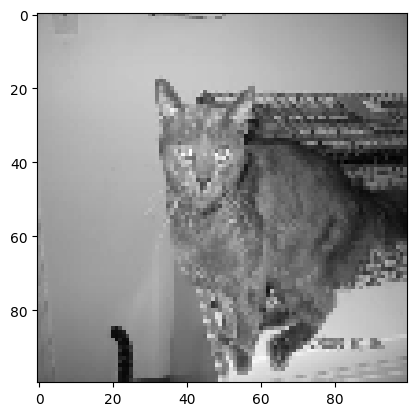

Label = 1


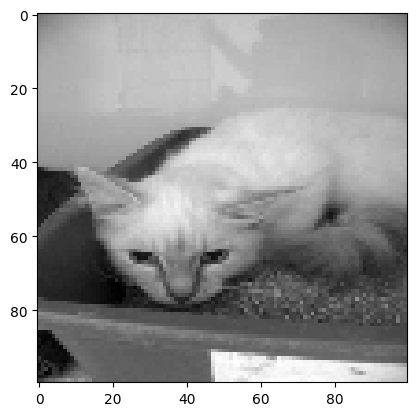

In [49]:
for image in random_image:
  print(f"Label = {y[image]}")
  plt.imshow(X[image],cmap="gray")
  plt.show()

In [36]:
random_images = X[np.random.choice(X.shape[0], size=100, replace=False)]

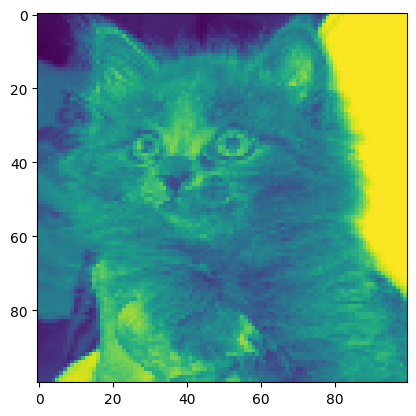

In [39]:
plt.imshow(random_images[0])

In [44]:
random_index = np.random.choice(X.shape[0], size=100, replace=False)
random_index

array([10672, 11520, 19401, 19830, 21213, 12542, 22575, 18082, 16726,
        9791, 24056, 18170, 20208, 19970,  3849, 17712, 12688, 13365,
       16482, 15347, 11390,  9010, 10515, 24515, 23266, 23864,  6186,
        5439, 22386,  8481,  6495,  7577,  3699,  9415, 20576,  3170,
       12851,  4149,  6430,  7729, 16247,  2663, 11201,  1910, 22705,
       24895,  1430, 14633,  1399, 23719, 24252,  2139,  9006, 10737,
       22563, 12675,  9426, 14043, 23770,  1686, 13901, 13065, 10206,
        4578, 18567,  5333,  8608, 22298, 23921, 13206, 11812, 12597,
        2905,  8597,  8055, 23371,  1662,  8487,  4397, 15942, 20966,
        4780, 24859, 13382,  3972,  6805,  9407, 13401, 10073,  5326,
       18426, 12187,  6058,  1627,  3381,  3864, 24481,   680,  6106,
         741])

In [45]:
random_images = X[random_index]

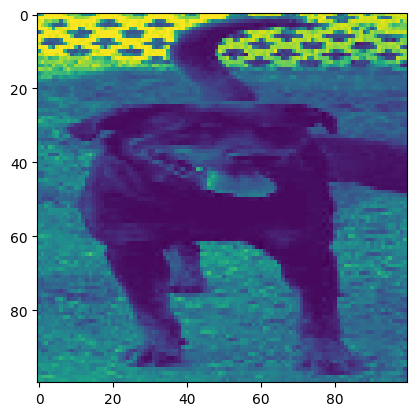

In [46]:
plt.imshow(random_images[0])

In [50]:
random_targets = y[random_index]
random_targets

array([0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1])

## Data Processing

Split X and y into training and testing sets.

Build a convolutional neural network with the following:

Sequential layers

At least two 2D convolutional layers using the 'relu' activation function and a (3,3) kernel size.

A MaxPooling2D layer after each 2D convolutional layer that has a pool size of (2,2).

A dense output layer using the 'sigmoid' activation function. Note: you can play around with the number of layers and nodes to try to get better performance.

Compile your model. Use the 'adam' optimizer. Determine which loss function and metric is most appropriate for this problem.

Fit your model using the training set.

Evaluate your model using the testing set.

Plot the distribution of probabilities for the testing set.

Define a function that will read in a new image and convert it to a 4 dimensional array of pixels (ask the instructor for help with this). Hint: numpy.reshape

Use the function defined above to read in the dog.jpg image that is saved in the AWS S3 bucket.

Use the neural network you created to predict whether the image is a dog or a cat.

In [77]:
from sklearn.model_selection import train_test_split

# X = numpy matrix / feature data
# y = numpy array / target values

X_train, X_test, y_train, y_test = train_test_split(
    random_images,
    random_targets,
    test_size=0.2,
    random_state=42
)

In [78]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 100, 100, 1)
(20, 100, 100, 1)
(80,)
(20,)


In [55]:
print(X.ndim)

4


In [64]:
model = Sequential()


In [65]:
# Define input layer
model.add(
  Input(
    shape=X_train.shape[1:],
    name="model_input",
  ),
)


In [66]:
# Define first hidden layer
model.add(
  Conv2D(
    name = "Conv1",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
    MaxPooling2D(pool_size=(2,2))
)


In [67]:
# Define second hidden layer
model.add(
  Conv2D(
    name = "Conv2",
    filters = 64,
    kernel_size = (3,3),
    activation = 'relu',
  )
)

model.add(
  MaxPooling2D(pool_size=(2,2))
)


In [68]:
# Flatten data to be used in output layer
model.add(
    Flatten()
)

# Define output layer
model.add(
  Dense(
    name = "output",
    units = 1,
    activation = 'sigmoid',
  )
)


#### Compile model

In [70]:
# Compile model
model.compile(
  optimizer = 'adam',
  loss = 'binary_crossentropy',
  metrics = ['accuracy'],
)


Fit Model

In [72]:
# Fit model
model.fit(X_train, y_train, epochs=2)

Epoch 1/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 538ms/step - accuracy: 0.4375 - loss: 29.8454
Epoch 2/2
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.5125 - loss: 20.2035


In [74]:
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │        33,857 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 214,277 (837.02 KB)

 Trainable params: 71,425 (279.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 142,852 (558.02 KB)

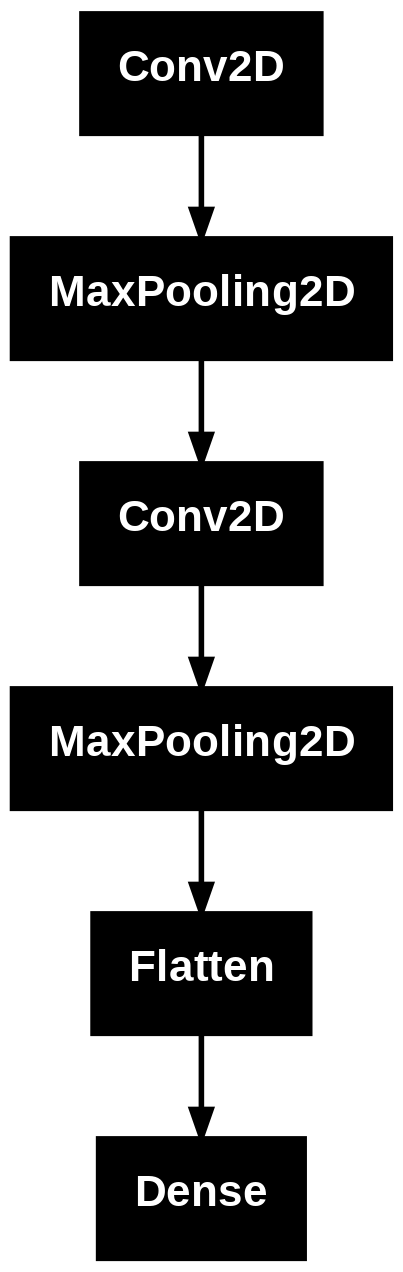

In [75]:
plot_model(model)

Evaluate Model

In [81]:
X_test.reshape( X_test.shape + (1,) ).shape

(20, 100, 100, 1, 1)

In [82]:
X_test.shape

(20, 100, 100, 1)

In [83]:
# Change test set to 4-D
# X_test = X_test.reshape( X_test.shape + (1,) )

# Evaluate model
val_loss, val_acc = model.evaluate(X_test, y_test)
print(val_loss)
print(val_acc)

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=uint8)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>